## Image classification

In this blog post, I classify images of cats and dogs using Tensorflow. I will use Tensorflow's `Datasets` functionalities to streamline the model training and testing process, get started on some image data preprocessing and augmentation, and use a pre-trained image classification model to achieve better performance.

First, let's import the requisite packages.

In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import utils, layers, models

We grab the dataset of cat and dog images, and split it into training and validation datasets, and then construct a test dataset from the validation data. All this can be done using convenience functions from `tensorflow.keras.utils`.

In [2]:
# location of data
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'

# download the data and extract it
path_to_zip = utils.get_file('cats_and_dogs.zip', origin=_URL, extract=True)

# construct paths
PATH = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

# parameters for datasets
BATCH_SIZE = 32
IMG_SIZE = (160, 160)

# construct train and validation datasets 
train_dataset = utils.image_dataset_from_directory(train_dir,
                                                   shuffle=True,
                                                   batch_size=BATCH_SIZE,
                                                   image_size=IMG_SIZE)

validation_dataset = utils.image_dataset_from_directory(validation_dir,
                                                        shuffle=True,
                                                        batch_size=BATCH_SIZE,
                                                        image_size=IMG_SIZE)

# construct the test dataset by taking every 5th observation out of the validation dataset
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)

68616192/68606236 [==============================] - 1s 0us/step
Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


Next, let's look at some random images to see what our data looks like. I've made a function to plot a row of cat images followed by a row of dog images.

In [3]:
def viz_2row():
  class_names = train_dataset.class_names
  plt.figure(figsize=(10, 10))
  for images, labels in train_dataset.take(1):
    # 0 is cat, 1 is dog
    cats = np.random.choice(np.where(labels==0)[0], size=3, replace=False)
    dogs = np.random.choice(np.where(labels==1)[0], size=3, replace=False)
    # get random indices of cats/dogs, then vstack them to be used for subplots
    m = np.vstack((cats,dogs))
    for j in range(2):
      for i in range(3):
        ax = plt.subplot(2, 3, 3*j + i + 1)
        plt.imshow(images[m[j,i]].numpy().astype("uint8"))
        plt.title(class_names[labels[m[j,i]]])
        plt.axis("off")

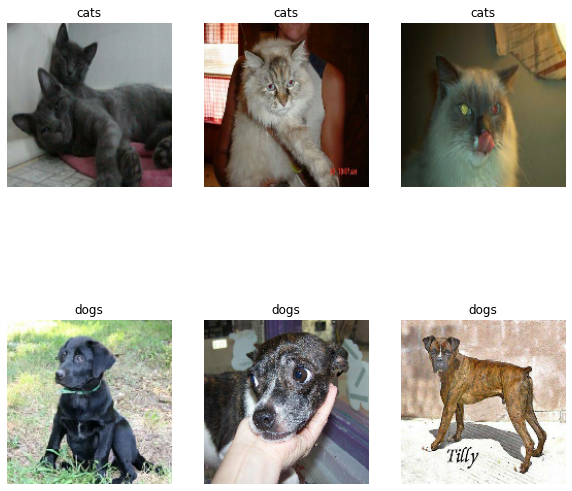

In [4]:
viz_2row()

This chunk below is a is technical code for rapidly reading data.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

Next, we count the number of labels in each class. This is to get an idea of how a baseline model that just guesses the most frequent class would perform.

In [6]:
labels_iterator= train_dataset.unbatch().map(lambda image, label: label).as_numpy_iterator()
ncats = 0
ndogs = 0
test = 0

# count labels
for i in labels_iterator:
  if i==0:
    ncats += 1
  elif i==1:
    ndogs += 1

print("Number of cats: ", ncats)
print("Number of dogs: ", ndogs)


Number of cats:  1000
Number of dogs:  1000


There are as many cats as dogs in the dataset. A baseline model that always guesses one way, or perhaps randomize, would be expected to guess right half the time. 

### First model

This first model has some basic layers for image classification. The `Conv2D` layers performs [convolution](https://homepages.inf.ed.ac.uk/rbf/HIPR2/convolve.htm) on the image (pixels represented as arrays), and `MaxPooling2D` layers basically works to go over each patch (here a 3 by 3 grid) of the image and picks out the maximum value in the patch. Then we `Flatten` the 2D images into a 1-dimensional vector. We also implement a drop-out layer that randomly discards a fraction of the nodes to prevent overfitting. Finally, the last layer is one that provides the classification, and therefore its output is set to the number of classes.

In [18]:
model1 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(160, 160, 3)),
    layers.MaxPooling2D((3,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((3,3)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(2) 
])
model1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [19]:
model1.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 158, 158, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 52, 52, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 50, 50, 32)        9248      
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 16, 16, 32)       0         
 2D)                                                             
                                                                 
 conv2d_11 (Conv2D)          (None, 14, 14, 64)        18496     
                                                                 
 flatten_3 (Flatten)         (None, 12544)            

Now we can fit the model on the training data.

In [20]:
# fit the model, saving history
history = model1.fit(train_dataset, 
                     epochs=20, 
                     validation_data=validation_dataset)


Epoch 1/20
63/63 [==============================] - 6s 78ms/step - loss: 11.3839 - accuracy: 0.5445 - val_loss: 0.6570 - val_accuracy: 0.6002
Epoch 2/20
63/63 [==============================] - 5s 74ms/step - loss: 0.6716 - accuracy: 0.5925 - val_loss: 0.6694 - val_accuracy: 0.6126
Epoch 3/20
63/63 [==============================] - 5s 68ms/step - loss: 0.6517 - accuracy: 0.6165 - val_loss: 0.6265 - val_accuracy: 0.6374
Epoch 4/20
63/63 [==============================] - 5s 68ms/step - loss: 0.6086 - accuracy: 0.6565 - val_loss: 0.6671 - val_accuracy: 0.6027
Epoch 5/20
63/63 [==============================] - 5s 69ms/step - loss: 0.5728 - accuracy: 0.6945 - val_loss: 0.7054 - val_accuracy: 0.6275
Epoch 6/20
63/63 [==============================] - 5s 69ms/step - loss: 0.4702 - accuracy: 0.7685 - val_loss: 0.6737 - val_accuracy: 0.6572
Epoch 7/20
63/63 [==============================] - 5s 70ms/step - loss: 0.4002 - accuracy: 0.8130 - val_loss: 0.7090 - val_accuracy: 0.6572
Epoch 8/20
6

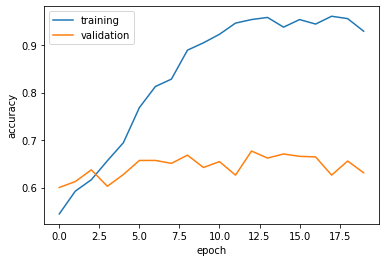

In [27]:
#plot accuracy metrics
plt.plot(history.history["accuracy"], label = "training")
plt.plot(history.history["val_accuracy"], label = "validation")
plt.gca().set(xlabel = "epoch", ylabel = "accuracy")
plt.legend()

**The validation accuracy of my model stabilized above 60%.** To achieve this, I worked off the layer configurations given in class. First I adjusted the input dimensions to match the image dimensions and the output dimensions to match the number of classes. Having tried tweaking the parameters of the convolutional layers, I experimented with the positioning of the dropout layer which improved model performance. The final validation accuracy is noticeably better than the baseline of 50%. Overfitting is an issue in this model, as the later epochs displayed much higher training accuracy than validation accuracy, although not to the extent that validation accuracy started falling significantly. 

### Data augmentation

Working with image data means that we can increase the size of our dataset by introducing variation that we want to teach the model. For example, we can add mirror images or rotations of our training data. 

In [21]:
# initialize a model with just a flip/rotate layer, to visualize effects
flip = tf.keras.Sequential([tf.keras.layers.RandomFlip('horizontal', seed=123),])

#rotate factor=0.25, i.e. 90 degrees either direction
rotate = tf.keras.Sequential(tf.keras.layers.RandomRotation(factor=0.25, seed=123))

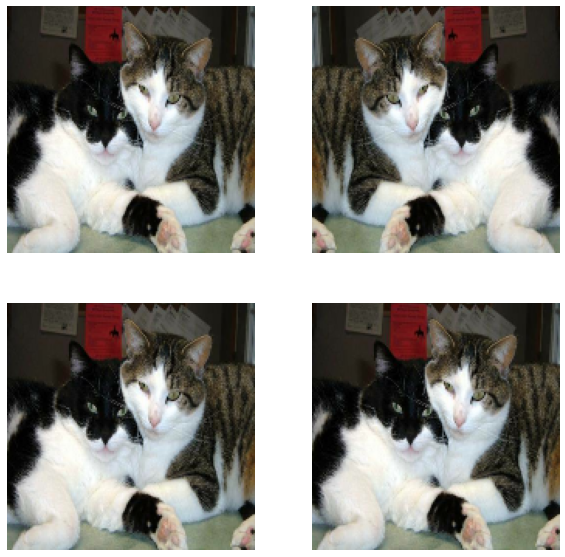

In [22]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    # manually set training=True, so the layer is active
    augmented_image = flip(tf.expand_dims(first_image, 0), training=True)
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

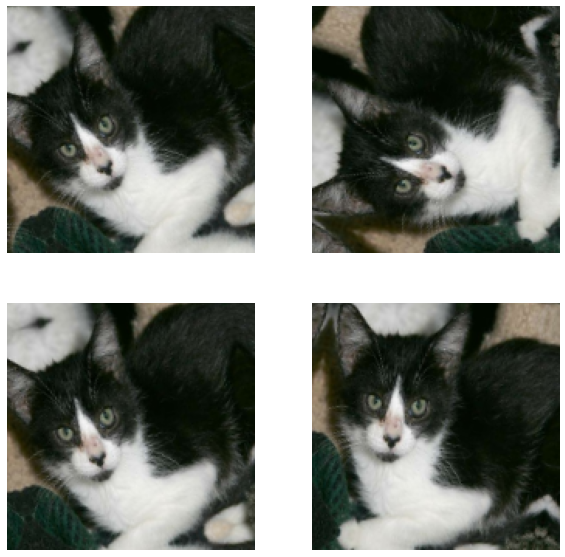

In [23]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    # manually set training=True, so the layer is active
    augmented_image = rotate(tf.expand_dims(first_image, 0), training=True)
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

Here, I fit a model that includes the data augmentations at the start.

In [24]:
model2 = models.Sequential([
    layers.RandomFlip('horizontal', input_shape=(160, 160, 3)),
    layers.RandomRotation(factor=0.2),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((3,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((3,3)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(2) 
])

model2.compile(optimizer='adam',
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=['accuracy'])

In [25]:
model2.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 random_flip_3 (RandomFlip)  (None, 160, 160, 3)       0         
                                                                 
 random_rotation_3 (RandomRo  (None, 160, 160, 3)      0         
 tation)                                                         
                                                                 
 conv2d_12 (Conv2D)          (None, 158, 158, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 52, 52, 32)       0         
 2D)                                                             
                                                                 
 conv2d_13 (Conv2D)          (None, 50, 50, 32)        9248      
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 16, 16, 32)      

In [26]:
history2 = model2.fit(train_dataset, 
                      epochs=20, 
                      validation_data=validation_dataset)


Epoch 1/20
63/63 [==============================] - 6s 77ms/step - loss: 3.9504 - accuracy: 0.5175 - val_loss: 0.7035 - val_accuracy: 0.5173
Epoch 2/20
63/63 [==============================] - 5s 79ms/step - loss: 0.6850 - accuracy: 0.5415 - val_loss: 0.6698 - val_accuracy: 0.5842
Epoch 3/20
63/63 [==============================] - 6s 93ms/step - loss: 0.6740 - accuracy: 0.5425 - val_loss: 0.6928 - val_accuracy: 0.5730
Epoch 4/20
63/63 [==============================] - 5s 72ms/step - loss: 0.6694 - accuracy: 0.5620 - val_loss: 0.6977 - val_accuracy: 0.5458
Epoch 5/20
63/63 [==============================] - 5s 73ms/step - loss: 0.6624 - accuracy: 0.5880 - val_loss: 0.7082 - val_accuracy: 0.5941
Epoch 6/20
63/63 [==============================] - 5s 72ms/step - loss: 0.6714 - accuracy: 0.5760 - val_loss: 0.6691 - val_accuracy: 0.5705
Epoch 7/20
63/63 [==============================] - 5s 72ms/step - loss: 0.6649 - accuracy: 0.5730 - val_loss: 0.6959 - val_accuracy: 0.5866
Epoch 8/20
63

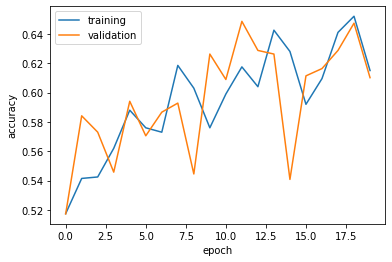

In [28]:
plt.plot(history2.history["accuracy"], label = "training")
plt.plot(history2.history["val_accuracy"], label = "validation")
plt.gca().set(xlabel = "epoch", ylabel = "accuracy")
plt.legend()

**The validation accuracy of this model ends up at around 60%.** The training accuracy was slightly lower than the first model, although overfitting did not seem to be an issue.

### Data preprocessing

Due to the input data being RGB images represented as values between 0 and 255, the models we've been training have to learn this idiosyncratic feature of the dataset. By scaling the input to between 0 and 1, we don't materially change the task, but save some processing time and power for the model. 

In [30]:
i = tf.keras.Input(shape=(160, 160, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(i)
preprocessor = tf.keras.Model(inputs = [i], outputs = [x])

In [31]:
model3 = models.Sequential([
    preprocessor,
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(factor=0.2),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((3,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((3,3)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(2) 
])

model3.compile(optimizer='adam',
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=['accuracy'])

In [32]:
model3.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_1 (Functional)        (None, 160, 160, 3)       0         
                                                                 
 random_flip_4 (RandomFlip)  (None, 160, 160, 3)       0         
                                                                 
 random_rotation_4 (RandomRo  (None, 160, 160, 3)      0         
 tation)                                                         
                                                                 
 conv2d_15 (Conv2D)          (None, 158, 158, 32)      896       
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 52, 52, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_16 (Conv2D)          (None, 50, 50, 32)       

In [33]:
history3 = model3.fit(train_dataset, 
                      epochs=20, 
                      validation_data=validation_dataset)


Epoch 1/20
63/63 [==============================] - 6s 77ms/step - loss: 0.7004 - accuracy: 0.5285 - val_loss: 0.6605 - val_accuracy: 0.5730
Epoch 2/20
63/63 [==============================] - 5s 74ms/step - loss: 0.6661 - accuracy: 0.5850 - val_loss: 0.6650 - val_accuracy: 0.5582
Epoch 3/20
63/63 [==============================] - 6s 90ms/step - loss: 0.6404 - accuracy: 0.6340 - val_loss: 0.6189 - val_accuracy: 0.6473
Epoch 4/20
63/63 [==============================] - 5s 80ms/step - loss: 0.6063 - accuracy: 0.6660 - val_loss: 0.6137 - val_accuracy: 0.6634
Epoch 5/20
63/63 [==============================] - 5s 74ms/step - loss: 0.5883 - accuracy: 0.6905 - val_loss: 0.5894 - val_accuracy: 0.6832
Epoch 6/20
63/63 [==============================] - 5s 75ms/step - loss: 0.5878 - accuracy: 0.6880 - val_loss: 0.6152 - val_accuracy: 0.6671
Epoch 7/20
63/63 [==============================] - 6s 85ms/step - loss: 0.5612 - accuracy: 0.7005 - val_loss: 0.5963 - val_accuracy: 0.6993
Epoch 8/20
63

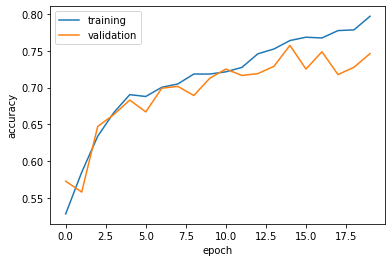

In [34]:
plt.plot(history3.history["accuracy"], label = "training")
plt.plot(history3.history["val_accuracy"], label = "validation")
plt.gca().set(xlabel = "epoch", ylabel = "accuracy")
plt.legend()

**The validation accuracy of this model reaches above 70%, much higher than either of the previous models.** There was also no sign of overfitting in this model as the training accuracy and validation accuracy increased at a similar pace.

### Transfer learning

Transfer learning is a way to borrow existing models that have been trained for related tasks. Here, I access an existing base model for image classification type tasks, and add the preprocessing and data augmentation layers.

In [35]:
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False

i = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(i, training = False)
base_model_layer = tf.keras.Model(inputs = [i], outputs = [x])

9420800/9406464 [==============================] - 0s 0us/step


In [36]:
model4 = models.Sequential([
    preprocessor,
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(factor=0.2),
    base_model_layer,
    layers.Flatten(),
    layers.Dense(2) 
])

model4.compile(optimizer='adam',
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=['accuracy'])
model4.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_1 (Functional)        (None, 160, 160, 3)       0         
                                                                 
 random_flip_5 (RandomFlip)  (None, 160, 160, 3)       0         
                                                                 
 random_rotation_5 (RandomRo  (None, 160, 160, 3)      0         
 tation)                                                         
                                                                 
 model_2 (Functional)        (None, 5, 5, 1280)        2257984   
                                                                 
 flatten_6 (Flatten)         (None, 32000)             0         
                                                                 
 dense_12 (Dense)            (None, 2)                 64002     
                                                     

In [37]:
history4 = model4.fit(train_dataset, 
                      epochs=20, 
                      validation_data=validation_dataset)


Epoch 1/20
63/63 [==============================] - 11s 107ms/step - loss: 0.5407 - accuracy: 0.9105 - val_loss: 0.0952 - val_accuracy: 0.9765
Epoch 2/20
63/63 [==============================] - 6s 84ms/step - loss: 0.4101 - accuracy: 0.9460 - val_loss: 0.2737 - val_accuracy: 0.9691
Epoch 3/20
63/63 [==============================] - 6s 84ms/step - loss: 0.4648 - accuracy: 0.9460 - val_loss: 0.2996 - val_accuracy: 0.9703
Epoch 4/20
63/63 [==============================] - 6s 85ms/step - loss: 0.4081 - accuracy: 0.9545 - val_loss: 0.1971 - val_accuracy: 0.9777
Epoch 5/20
63/63 [==============================] - 6s 85ms/step - loss: 0.3767 - accuracy: 0.9530 - val_loss: 0.3202 - val_accuracy: 0.9703
Epoch 6/20
63/63 [==============================] - 6s 85ms/step - loss: 0.5789 - accuracy: 0.9485 - val_loss: 0.2363 - val_accuracy: 0.9765
Epoch 7/20
63/63 [==============================] - 6s 87ms/step - loss: 0.4172 - accuracy: 0.9625 - val_loss: 0.2648 - val_accuracy: 0.9752
Epoch 8/20


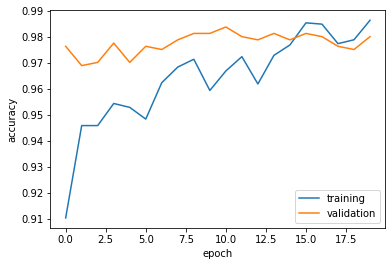

In [38]:
plt.plot(history4.history["accuracy"], label = "training")
plt.plot(history4.history["val_accuracy"], label = "validation")
plt.gca().set(xlabel = "epoch", ylabel = "accuracy")
plt.legend()

**The validation accuracy of this model is consistently above 97%.** Although training accuracy goes above validation accuracy eventually, the model does not seem to be overfitted as validation accuracy remains high.

In [39]:
#evaluate on test data
loss, accuracy = model4.evaluate(test_dataset)
print('Test accuracy :', accuracy)

6/6 [==============================] - 1s 84ms/step - loss: 0.0134 - accuracy: 0.9948
Test accuracy : 0.9947916865348816


The final model obtained a test accuracy of over 99%. 